## AI-Powered Climate Smart Farm Advisor

### Project Information
The **AI-Powered Climate Smart Farm Advisor** is a Machine Learning-based agricultural decision support system that helps farmers make informed decisions. It provides recommendations for crop selection, yield prediction, irrigation scheduling, fertilizer application, disease risk assessment, sowing risk prediction, and Minimum Support Price (MSP) using agricultural and weather datasets.

### Domain
**Agriculture | Artificial Intelligence | Machine Learning | Data Science**

### Industry
**Agricultural Technology (AgriTech)**, focusing on data-driven farming solutions to improve productivity, optimize resource utilization, and promote sustainable agriculture.

### Problem Statement
Farmers face challenges such as unpredictable weather, climate change, water scarcity, and limited access to personalized agricultural recommendations. This project addresses these issues by integrating multiple Machine Learning models into a single intelligent system that provides accurate, data-driven farming recommendations
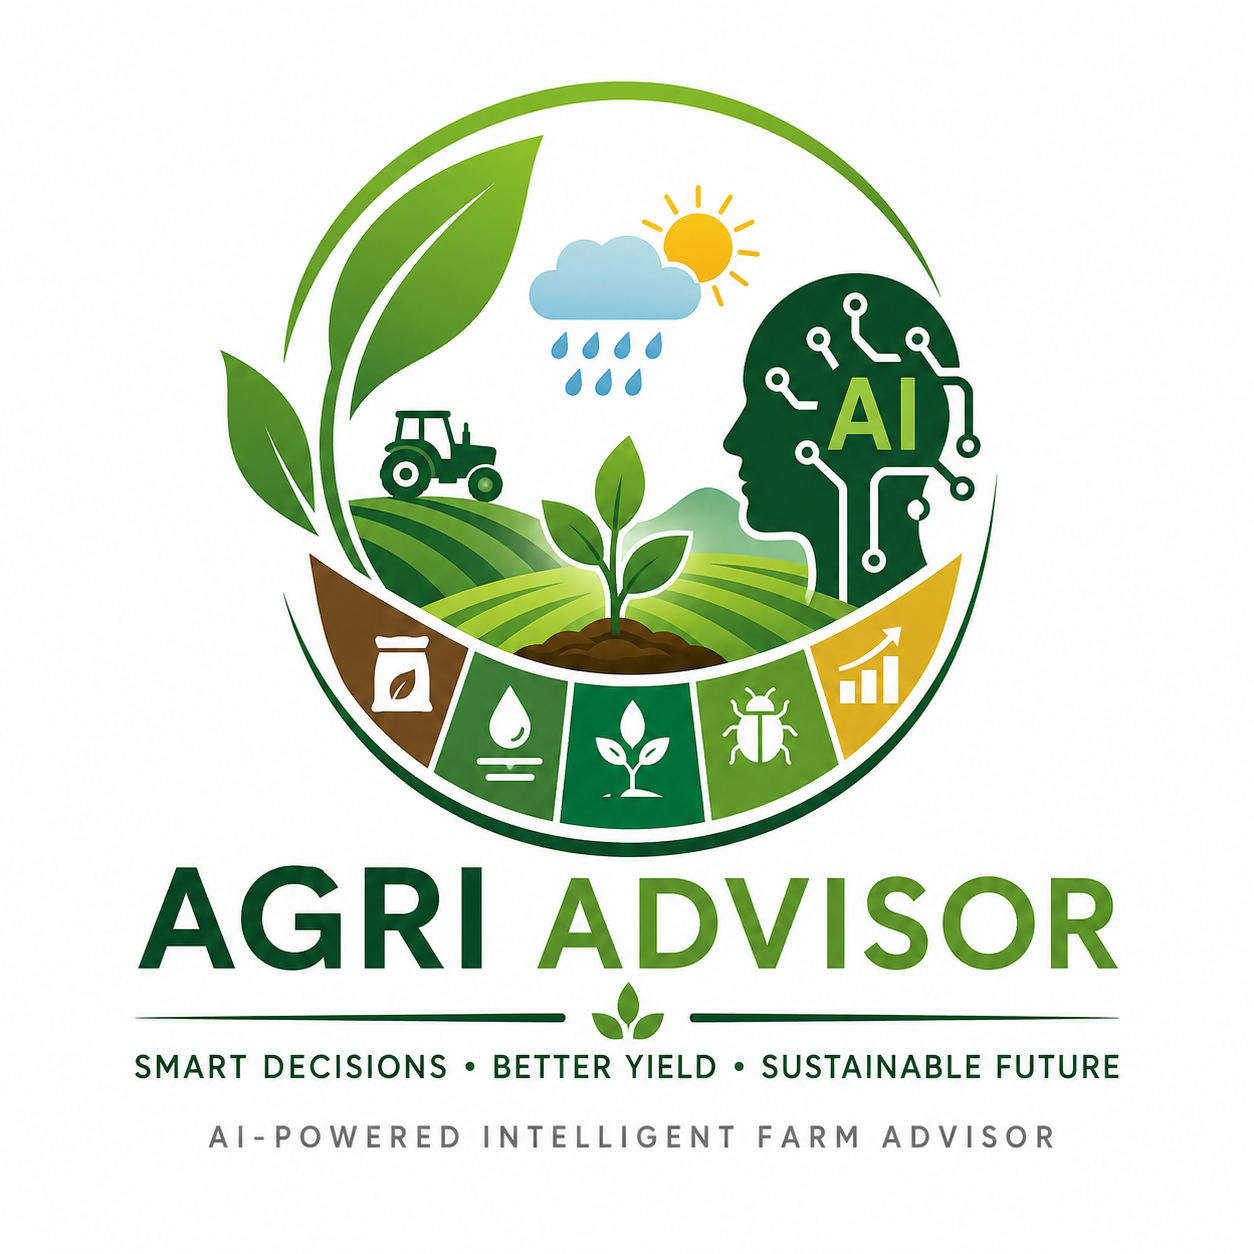

In [2]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [3]:
!pip install sqlalchemy
!pip install pymysql

In [4]:
url = URL.create(
    "mysql+pymysql",
    username="root",
    password="Sanju1477",
    host="localhost",
    port=3306,
    database="agricultur")
engine = create_engine(url)

In [5]:
try:
    with engine.connect() as conn:
        print("Connected successfully!")
except Exception as e:
    print(e)

Connected successfully!


## 0. Data

- The project uses a comprehensive agricultural market price dataset covering multiple crops across different states and districts in India. The     dataset contains historical records of crop arrivals and modal market prices, which are used to analyze market trends and develop a machine         learning model for crop market price prediction.

## Source
- Agmarknet (Agricultural Marketing Information System)
- Open-Meteo API
- Data.gov
- FAO Webpage
- Soil grids

In [6]:
market = pd.read_csv(r"all_crops.csv")

In [7]:
market.columns = market.columns.str.strip()

In [8]:
print(market.columns.tolist())

['State', 'District', 'Commodity', 'Date', 'Arrival Quantity', 'Market Price', 'Price Unit']


In [9]:
market.rename(columns={
    "Arrival Quantity": "Arrival_Quantity",
    "Market Price": "Market_Price",
    "Price Unit": "Price_Unit"
}, inplace=True)

In [10]:
market.to_sql(name="market_price",con=engine,if_exists="replace", index=False)

60000

## 0.1) Load Data From Mysql

In [11]:
market = pd.read_sql("SELECT * FROM market_price", engine)

## Basic Inspection

In [12]:
market.head()

,State,District,Commodity,Date,Arrival_Quantity,Market_Price,Price_Unit
0,Telangana,Ranga Reddy,Mango,04-09-2024,502.20000,4075.000000,Rs./Quintal
1,Telangana,Suryapet,Maize,10-12-2025,0.00000,1923.969437,Rs./Quintal
2,Telangana,Khammam,Cotton,1/26/2025,35.75751,7199.022244,Rs./Quintal
3,Telangana,Bhadradri Kothagudem,Cotton,11/19/2024,209.40000,7458.450000,Rs./Quintal
4,Telangana,Asifabad,Cotton,02-07-2025,1422.40000,7421.000000,Rs./Quintal


In [13]:
market.tail()

,State,District,Commodity,Date,Arrival_Quantity,Market_Price,Price_Unit
59995,Telangana,Ranga Reddy,Grapes,5/27/2024,4.289686,2448.574731,Rs./Quintal
59996,Telangana,Nirmal,Maize,9/16/2024,0.000000,2384.807909,Rs./Quintal
59997,Telangana,Jagtial,Maize,2/24/2024,12.900000,2112.630000,Rs./Quintal
59998,Telangana,Ranga Reddy,Grapes,09-07-2025,2.100000,2850.000000,Rs./Quintal
59999,Telangana,Vikarabad,Maize,4/27/2026,504.098305,1861.671939,Rs./Quintal


In [14]:
market.sample(5)

,State,District,Commodity,Date,Arrival_Quantity,Market_Price,Price_Unit
15660,Telangana,Nirmal,Maize,6/20/2026,9.552278,2288.601240,Rs./Quintal
400,Telangana,Warangal,Grapes,06-08-2025,1.000000,5000.000000,Rs./Quintal
38791,Telangana,Khammam,Maize,5/25/2026,23.865302,2343.888469,Rs./Quintal
2596,Telangana,Mancherial,Mango,4/21/2024,381.062780,1464.224060,Rs./Quintal
6585,Telangana,Jogulamba Gadwal,Maize,11/27/2024,197.857895,2233.460274,Rs./Quintal


In [15]:
market.shape

(60000, 7)

In [16]:
market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             60000 non-null  object 
 1   District          60000 non-null  object 
 2   Commodity         60000 non-null  object 
 3   Date              60000 non-null  object 
 4   Arrival_Quantity  60000 non-null  float64
 5   Market_Price      60000 non-null  float64
 6   Price_Unit        60000 non-null  object 
dtypes: float64(2), object(5)
memory usage: 3.2+ MB


In [17]:
market.columns

Index(['State', 'District', 'Commodity', 'Date', 'Arrival_Quantity',
       'Market_Price', 'Price_Unit'],
      dtype='object')

In [18]:
market.dtypes

State                object
District             object
Commodity            object
Date                 object
Arrival_Quantity    float64
Market_Price        float64
Price_Unit           object
dtype: object

## 1) Data Validation

In [19]:
market.describe(include="all")

,State,District,Commodity,Date,Arrival_Quantity,Market_Price,Price_Unit
count,60000,60000,60000,60000,60000.000000,60000.000000,60000
unique,2,46,14,987,NaN,NaN,1
top,Telangana,Ranga Reddy,Maize,11/28/2024,NaN,NaN,Rs./Quintal
freq,49768,12937,20771,107,NaN,NaN,60000
mean,NaN,NaN,NaN,NaN,225.590998,3759.421719,NaN
std,NaN,NaN,NaN,NaN,904.418579,2673.205354,NaN
min,NaN,NaN,NaN,NaN,0.000000,229.074802,NaN
25%,NaN,NaN,NaN,NaN,4.560149,2022.000000,NaN
50%,NaN,NaN,NaN,NaN,27.983150,2391.906598,NaN
75%,NaN,NaN,NaN,NaN,110.986078,6600.000000,NaN


In [20]:
market.isnull().sum()

State               0
District            0
Commodity           0
Date                0
Arrival_Quantity    0
Market_Price        0
Price_Unit          0
dtype: int64

In [21]:
market.duplicated().sum()

np.int64(0)

In [22]:
market.nunique()

State                   2
District               46
Commodity              14
Date                  987
Arrival_Quantity    37300
Market_Price        42508
Price_Unit              1
dtype: int64

## 1.1) Change Dtype Of Date Column

In [23]:
market["Date"].head(10)

0    04-09-2024
1    10-12-2025
2     1/26/2025
3    11/19/2024
4    02-07-2025
5    08-10-2024
6     3/28/2025
7    05-05-2025
8    05-02-2025
9    10-09-2025
Name: Date, dtype: object

In [24]:
market["Date"] = pd.to_datetime(market["Date"],format="mixed",errors="coerce")

In [25]:
market["Day"] = market["Date"].dt.day
market["Month"] = market["Date"].dt.month
market["Year"] = market["Date"].dt.year
market["Quarter"] = market["Date"].dt.quarter

### 1.2) Drop The Unwanted Column For My Dataset

In [26]:
market.drop(["Date"],axis = 1 , inplace = True)

In [27]:
market.drop(["Price_Unit"],axis = 1 , inplace = True)

### Change The Index Location

In [28]:
col = market.pop("Commodity")
market.insert(0, "Commodity", col)

In [29]:
col = market.pop("Market_Price")
market.insert(8, "Market_Price", col)

In [30]:
col = market.pop("Arrival_Quantity")
market.insert(7, "Arrival_Quantity", col)

In [31]:
market.head()

,Commodity,State,District,Day,Month,Year,Quarter,Arrival_Quantity,Market_Price
0,Mango,Telangana,Ranga Reddy,9,4,2024,2,502.20000,4075.000000
1,Maize,Telangana,Suryapet,12,10,2025,4,0.00000,1923.969437
2,Cotton,Telangana,Khammam,26,1,2025,1,35.75751,7199.022244
3,Cotton,Telangana,Bhadradri Kothagudem,19,11,2024,4,209.40000,7458.450000
4,Cotton,Telangana,Asifabad,7,2,2025,1,1422.40000,7421.000000


In [32]:
market.describe()

,Day,Month,Year,Quarter,Arrival_Quantity,Market_Price
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,15.665567,6.038633,2024.837717,2.347433,225.590998,3759.421719
std,8.807946,3.410738,0.755154,1.113752,904.418579,2673.205354
min,1.000000,1.000000,2023.000000,1.000000,0.000000,229.074802
25%,8.000000,3.000000,2024.000000,1.000000,4.560149,2022.000000
50%,16.000000,5.000000,2025.000000,2.000000,27.983150,2391.906598
75%,23.000000,9.000000,2025.000000,3.000000,110.986078,6600.000000
max,31.000000,12.000000,2026.000000,4.000000,36780.720230,26020.160030


# **EDA**

## UNIVARIATE ANALYSIS
### Using Histogram,Box Plot,Violin Plot & KDE Plot

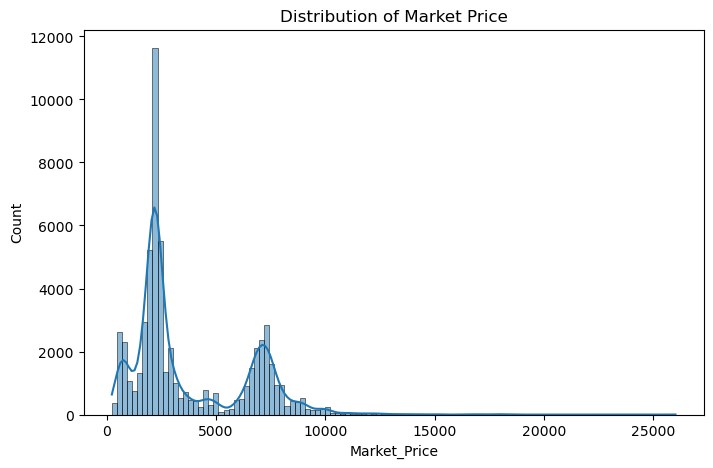

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(market["Market_Price"], kde=True)
plt.title("Distribution of Market Price")
plt.show()

## Insight
- The histogram shows the distribution of Market Price across all crops.
- If the distribution is right-skewed, it indicates that most crops are sold at lower prices, while only a few crops have very high prices.
-  variation in prices suggests that crop type and market conditions significantly influence market prices.

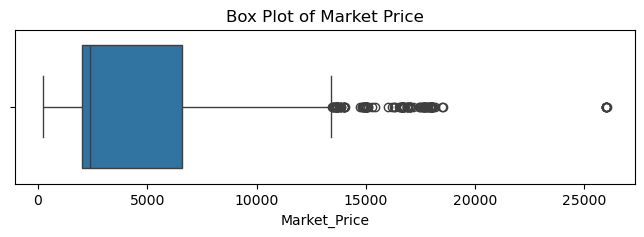

In [34]:
plt.figure(figsize=(8,2))
sns.boxplot(x=market["Market_Price"])
plt.title("Box Plot of Market Price")
plt.show()

## Insight
- The box plot identifies the spread of market prices and highlights potential outliers.
- Outliers represent crops or market transactions with exceptionally high or low prices.
- These outliers may occur due to seasonal demand, limited supply, premium-quality produce, or regional market differences.

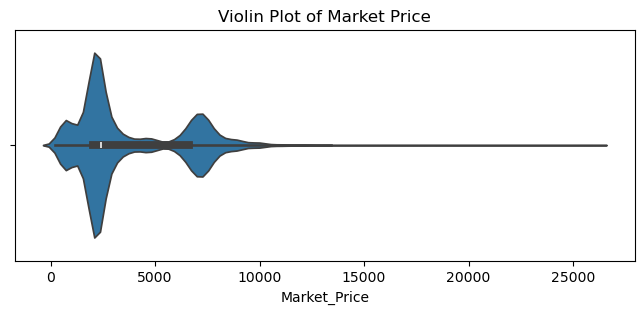

In [35]:
plt.figure(figsize=(8,3))
sns.violinplot(x=market["Market_Price"])
plt.title("Violin Plot of Market Price")
plt.show()

## Insight
- The violin plot combines a box plot with a density plot to show the distribution of market prices.
- Wider sections indicate price ranges where observations are concentrated.
- The plot helps identify multiple price peaks and the overall variability of crop prices.

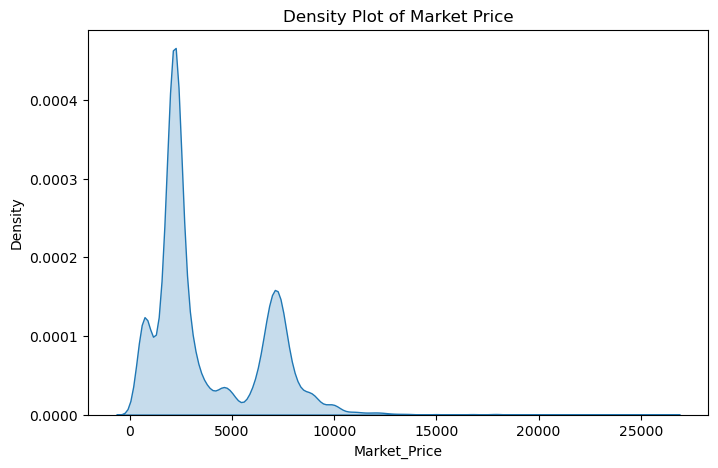

In [36]:
plt.figure(figsize=(8,5))
sns.kdeplot(market["Market_Price"], fill=True)
plt.title("Density Plot of Market Price")
plt.show()

## Insight
- The KDE plot provides a smooth representation of the probability density of market prices.
- Peaks indicate the most common market price ranges.
- This helps understand where the majority of observations are concentrated.

# **BIVARIATE ANALYSIS**
### Using scatterplot,Boxplot & Bar Plot

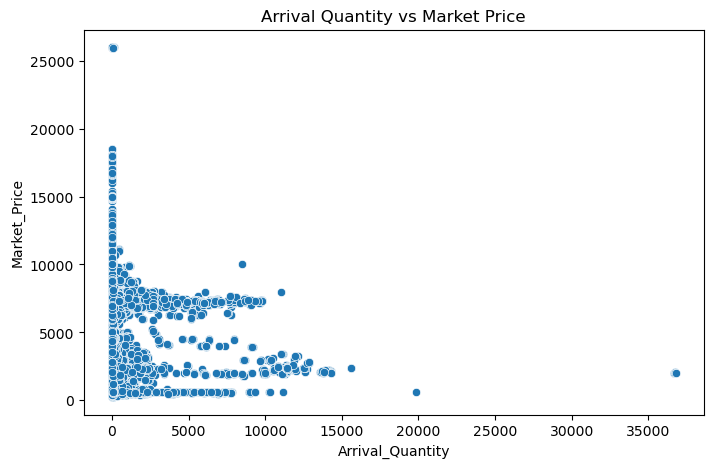

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=market,x="Arrival_Quantity",y="Market_Price")
plt.title("Arrival Quantity vs Market Price")
plt.show()

## Insight
- The scatter plot illustrates the relationship between Arrival Quantity and Market Price.
- If a negative trend is observed, higher arrivals are associated with lower prices due to increased supply.
- If no clear pattern exists, additional factors such as crop type or location may influence prices.

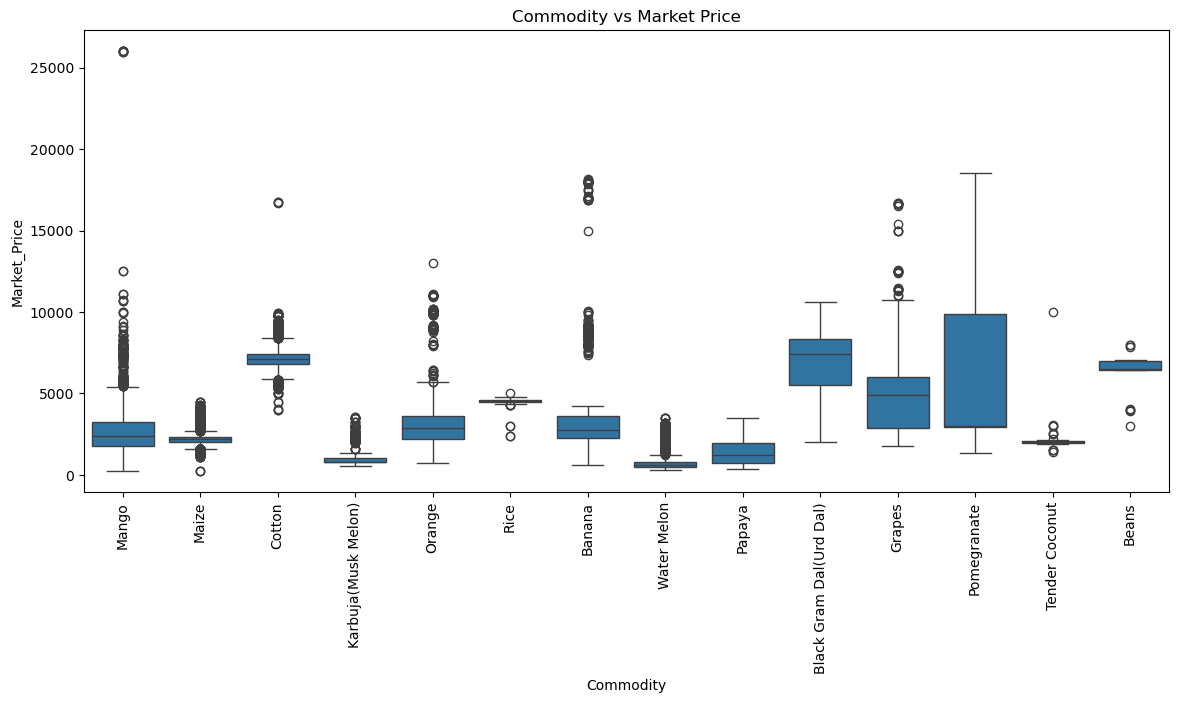

In [38]:
plt.figure(figsize=(14,6))
sns.boxplot(data=market,x="Commodity",y="Market_Price")
plt.xticks(rotation=90)
plt.title("Commodity vs Market Price")
plt.show()

## Insight
- Different commodities exhibit distinct market price distributions.
- Some crops consistently have higher median prices, while others show greater price variability.
- Price differences reflect variations in demand, production costs, perishability, and market conditions.

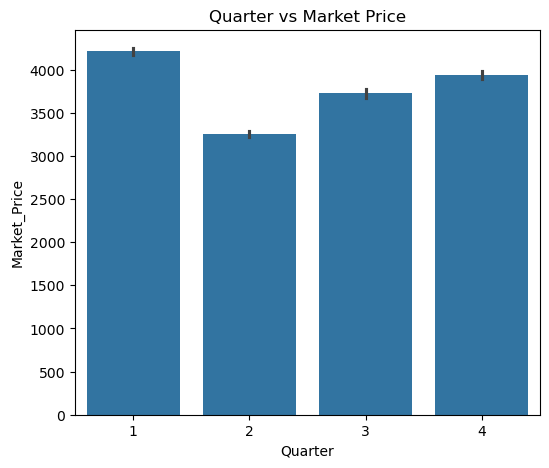

In [39]:
plt.figure(figsize=(6,5))
sns.barplot(data=market,x="Quarter",y="Market_Price")
plt.title("Quarter vs Market Price")
plt.show()

## Insight
- Average market prices vary across quarters of the year.
- Seasonal production cycles and harvesting periods contribute to these fluctuations.
- Quarter-wise analysis supports long-term market planning.

# **Multivariate Analysis**
## Using Heatmap, pairplot, scatterplot & boxplot

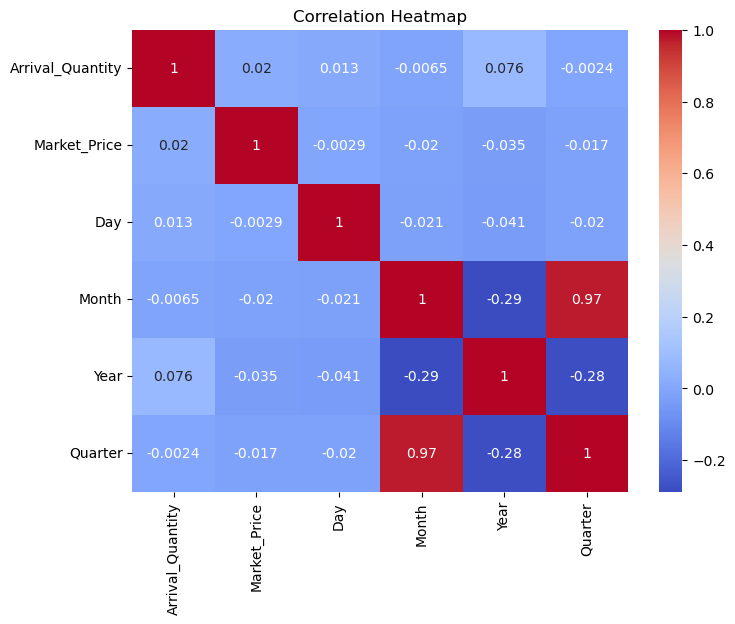

In [40]:
plt.figure(figsize=(8,6))
sns.heatmap(
    market[["Arrival_Quantity","Market_Price","Day","Month","Year","Quarter"]].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

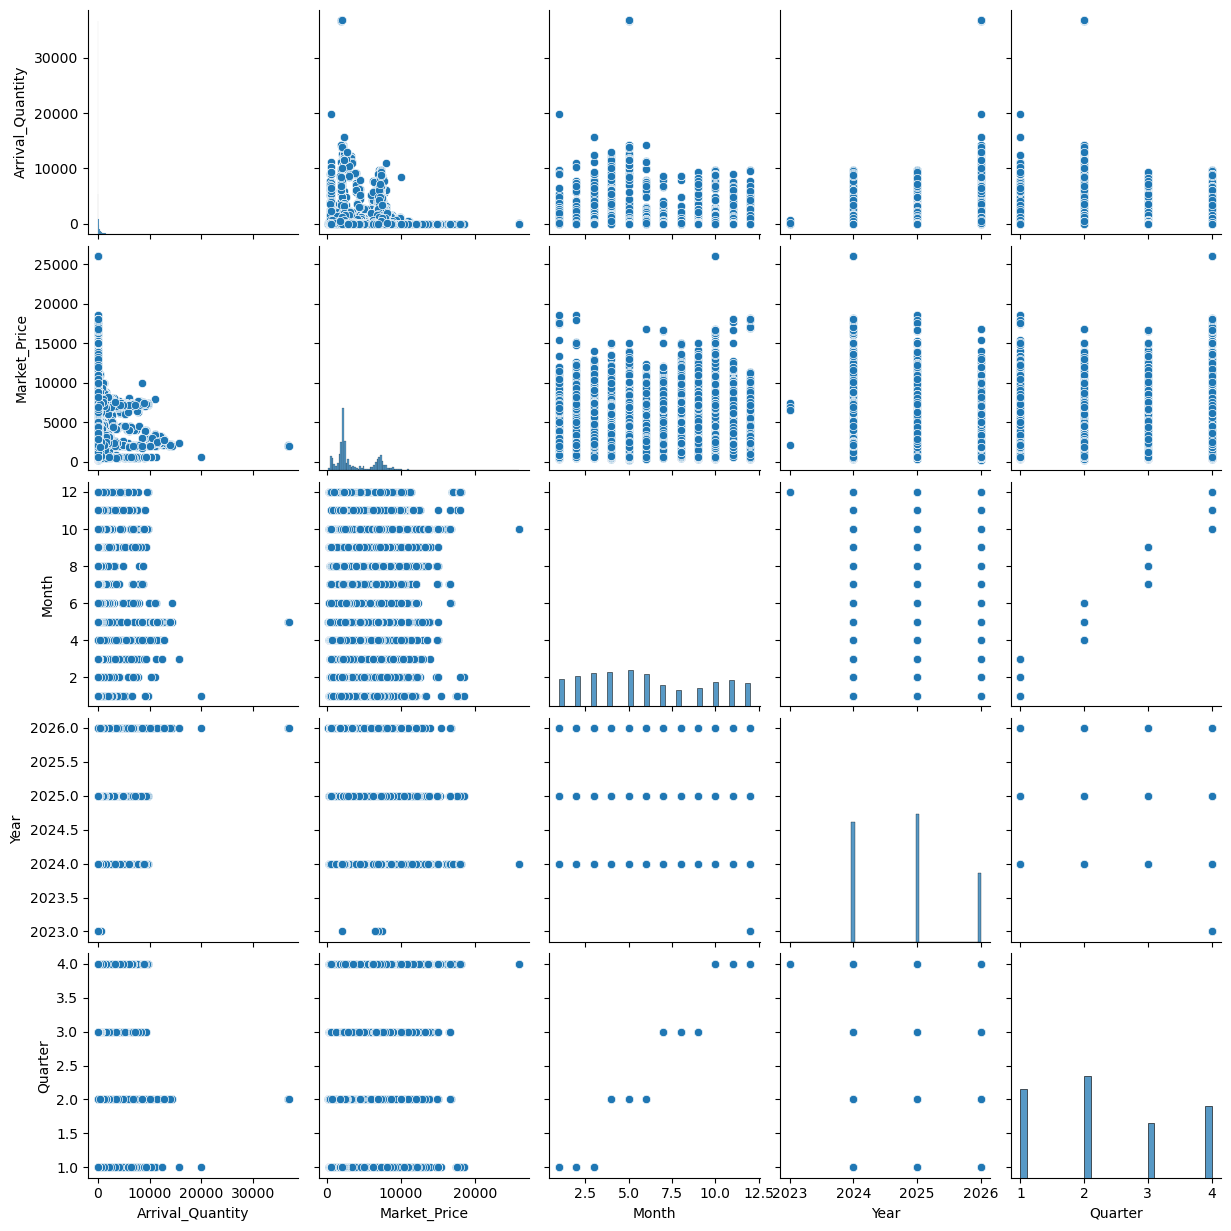

In [41]:
sns.pairplot(market[["Arrival_Quantity","Market_Price","Month","Year","Quarter"]])
plt.show()

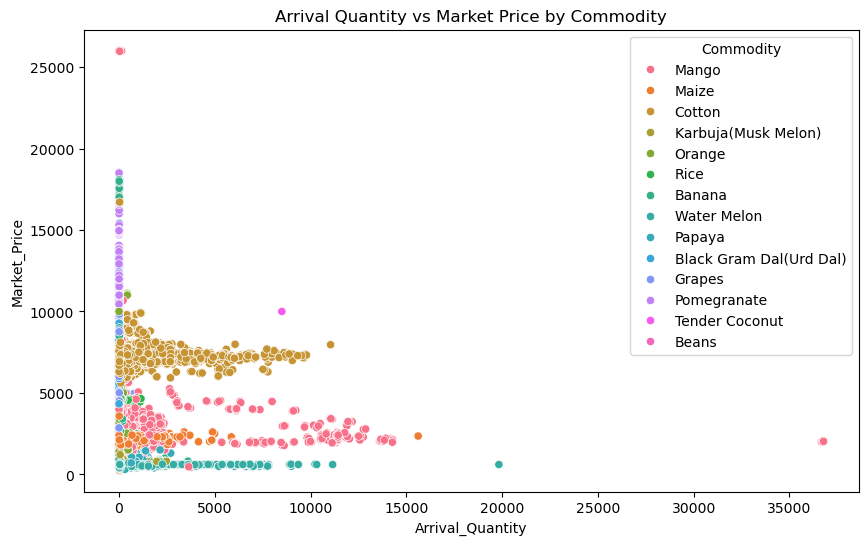

In [42]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=market,x="Arrival_Quantity",y="Market_Price",hue="Commodity")
plt.title("Arrival Quantity vs Market Price by Commodity")
plt.show()

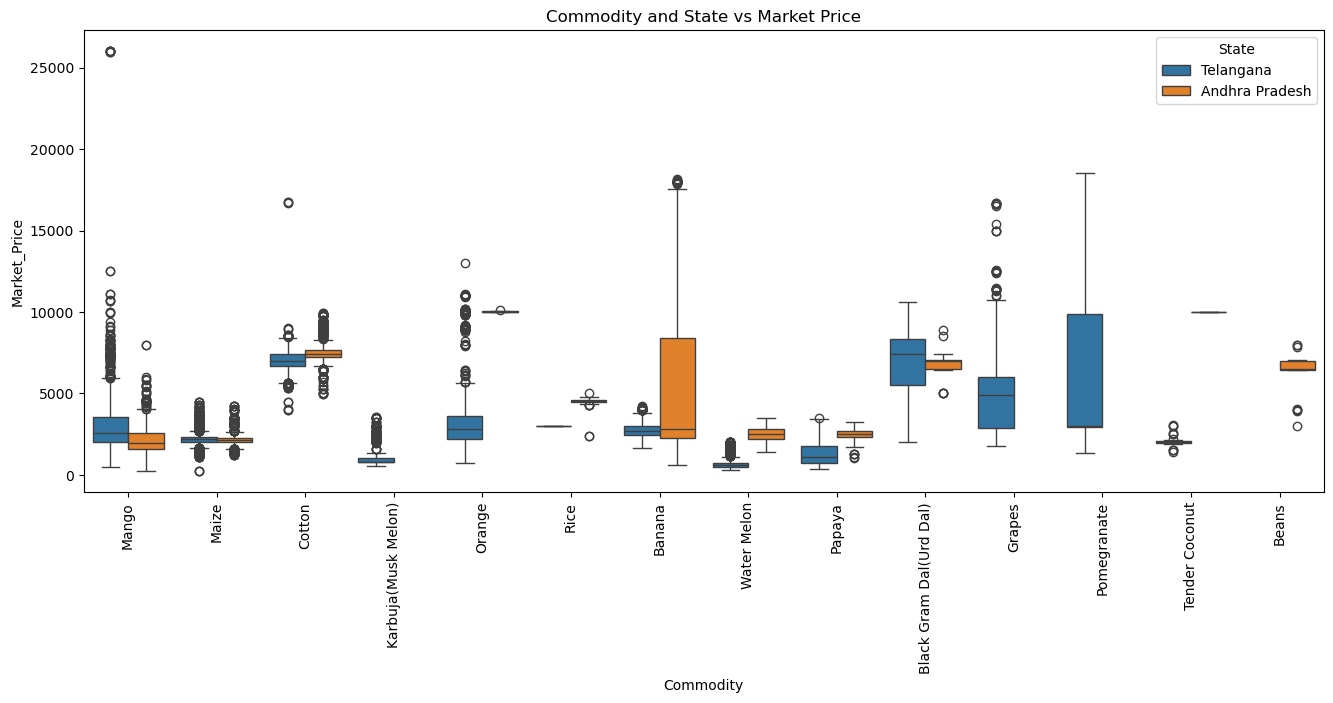

In [43]:
plt.figure(figsize=(16,6))
sns.boxplot(data=market,x="Commodity",y="Market_Price", hue="State")
plt.xticks(rotation=90)
plt.title("Commodity and State vs Market Price")
plt.show()

# **EDA Summary**
- ***Market prices show considerable variation across crops, states, and districts.***
- ***Seasonal patterns indicate that Month and Quarter influence prices.***
- ***Arrival Quantity has a noticeable relationship with market price and is an important predictive feature.***
- ***Commodity type is one of the strongest factors affecting market prices.***
- ***Regional differences suggest that State and District should be retained as input features.***
- ***The dataset contains sufficient variability for building a robust XGBoost regression model to predict crop market prices.***

# 

# Feature Encoding
- Finding Out The Data Is Ordinal or Nominal

In [44]:
market.groupby("Commodity")["Market_Price"].mean().sort_values(ascending=False)

Commodity
Cotton                     7138.109831
Black Gram Dal(Urd Dal)    6929.248779
Beans                      6261.936359
Pomegranate                5803.200572
Grapes                     4968.888424
Rice                       4555.614939
Banana                     4094.894567
Orange                     3694.466268
Mango                      2668.559747
Tender Coconut             2165.399803
Maize                      2155.594842
Papaya                     1325.947906
Karbuja(Musk Melon)        1002.205314
Water Melon                 818.221502
Name: Market_Price, dtype: float64

In [45]:
market.groupby("District")["Market_Price"].mean().sort_values(ascending=False)

District
Guntur                   7266.045642
Rajanna Siricilla        7147.318579
Nalgonda                 6880.910233
SPSR Nellore             6680.751340
Peddapalli               6668.017486
Hanumakonda              6648.870269
Chittor                  6575.117075
Alluri Sitharama Raju    6261.936359
Bhupalapally             6153.096722
Mancherial               5635.126276
Mulugu                   5415.803741
Kurnool                  5127.824409
Asifabad                 5035.070147
Karimnagar               4960.793940
Khammam                  4918.136679
Mahabubabad              4720.149951
Warangal                 4531.616745
Nagarkurnool             4409.060961
Adilabad                 4359.184235
NTR                      4345.393528
Nirmal                   4319.022995
Bhadradri Kothagudem     4234.922550
Suryapet                 3678.315235
Siddipet                 3570.845361
Vikarabad                3215.532381
Jogulamba Gadwal         2911.807058
East Godavari            2666

### Categorical variables (Commodity and District) were encoded using a custom rank-based mapping, where categories with higher average market prices were assigned higher numerical labels. This mapping was fixed before model training and consistently applied to all records."

In [46]:
commodity_mapping = {"Cotton": 14,"Black Gram Dal(Urd Dal)": 13,
    "Beans": 12,"Pomegranate": 11,"Grapes": 10,"Rice": 9,
    "Banana": 8,"Orange": 7,"Mango": 6,"Tender Coconut": 5,
    "Maize": 4,"Papaya": 3,"Karbuja(Musk Melon)": 2,"Water Melon": 1}

market["Commodity"] = market["Commodity"].map(commodity_mapping)

In [47]:
market["Commodity"].value_counts().sort_index()

Commodity
1      3045
2      2039
3      3028
4     20771
5        66
6      4423
7      2354
8      3025
9       719
10     3146
11     2587
12       24
13     1486
14    13287
Name: count, dtype: int64

In [48]:
district_mapping = {"Guntur": 46,"Rajanna Siricilla": 45,"Nalgonda": 44,"SPSR Nellore": 43,
    "Peddapalli":42,"Hanumakonda" : 41,"Chittor":40,"Alluri Sitharama Raju":39,
    "Bhupalapally":38,"Mancherial":37,"Mulugu":36,"Kurnool":35,"Asifabad":34,"Karimnagar":33,
    "Khammam":32,"Mahabubabad":31,"Warangal":30,"Nagarkurnool":29,"Adilabad":28,"NTR":27,
    "Nirmal":26,"Bhadradri Kothagudem":25,"Suryapet":24,"Siddipet":23,"Vikarabad":22,"Jogulamba Gadwal":21,
    "East Godavari":20,"Nandyal":19,"Sri Sathya Sai":18,"Dr.B.R.A.Konaseema":17,"Ranga Reddy":16,"Jagtial":15,
    "Eluru":14,"Mahbubnagar":13,"YSR Kadapa":12,"Wanaparthy":11,"Sangareddy":10,"Bapatla":9,"Ananthapuramu":8,
    "Medak":7,"Jangaon":6,"Kamareddy":5,"Medchal Malkajgiri":4,"Nizamabad":3,"Tirupathi":2,"Vijayanagaram":1}

market["District"] = market["District"].map(district_mapping)

In [49]:
market["State"].unique()

array(['Telangana', 'Andhra Pradesh'], dtype=object)

In [50]:
State_mapping = {"Telangana":1,"Andhra Pradesh":0}
market["State"] = market["State"].map(State_mapping)

In [51]:
print(market[["Commodity","District","State"]].head())

   Commodity  District  State
0          6        16      1
1          4        24      1
2         14        32      1
3         14        25      1
4         14        34      1


In [54]:
import joblib
encoders = {
    "commodity_mapping": commodity_mapping,
    "state_mapping": State_mapping,
    "district_mapping": district_mapping
}

joblib.dump(encoders, "Market_Label_Mappings.pkl")

print("All mappings saved successfully!")

All mappings saved successfully!


## Import Required Modules

The required machine learning libraries were imported to perform model training, evaluation, hyperparameter tuning, and result visualization.

In [55]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
%pip install xgboost
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from sklearn.model_selection import GridSearchCV
import joblib
import warnings
warnings.filterwarnings("ignore")

Note: you may need to restart the kernel to use updated packages.


## Feature and Target Selection

The dataset was divided into independent variables (features) and the dependent variable (target) for model development.

In [56]:
X = market.drop("Market_Price", axis=1)

y = market["Market_Price"]

## Train-Test Split

The dataset was split into training and testing datasets using an 80:20 ratio.

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Model Initialization

Multiple regression algorithms were initialized to identify the best-performing model for market price prediction.

In [58]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42),

    "XGBoost": XGBRegressor(random_state=42)

}

## Model Evaluation Function

A reusable function was developed to train each regression model, generate predictions, and evaluate performance using standard regression metrics.

In [59]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)

    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)

    test_r2 = r2_score(y_test, y_test_pred)

    mae = mean_absolute_error(y_test, y_test_pred)

    mse = mean_squared_error(y_test, y_test_pred)

    rmse = np.sqrt(mse)

    return [

        train_r2,

        test_r2,

        mae,

        mse,

        rmse

    ]

## Model Training

Each regression algorithm was trained using the training dataset, and its performance was evaluated on the testing dataset.

In [60]:
results = []

for name, model in models.items():

    result = evaluate_model(

        model,

        X_train,

        X_test,

        y_train,

        y_test

    )

    results.append([name] + result)

## Model Comparison

The performance of all regression models was compared using evaluation metrics to identify the most suitable algorithm.

In [61]:
comparison = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Train R2",

        "Test R2",

        "MAE",

        "MSE",

        "RMSE"

    ]

)

comparison

,Model,Train R2,Test R2,MAE,MSE,RMSE
0,Linear Regression,0.717703,0.712747,813.043447,2.064410e+06,1436.805406
1,Decision Tree,0.999843,0.935031,204.228320,4.669152e+05,683.311923
2,Random Forest,0.994380,0.961134,184.280515,2.793192e+05,528.506569
3,Gradient Boosting,0.880472,0.874161,483.785080,9.043697e+05,950.983555
4,XGBoost,0.962646,0.946984,277.403075,3.810091e+05,617.259322


## Model Comparison

- Five regression algorithms were trained and evaluated to identify the most suitable model for agricultural market price prediction. The models were    assessed using Train R², Test R², Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

- Among all the evaluated models, the Random Forest Regressor achieved the highest Test R² score (0.9611) and the lowest prediction error (RMSE =        528.51), indicating superior predictive performance and strong generalization capability.

- Although the Decision Tree Regressor achieved an almost perfect training score, its large gap between training and testing performance indicates
  overfitting. Linear Regression showed the lowest predictive performance due to its inability to capture the complex nonlinear relationships in the     dataset. XGBoost also performed well but was slightly outperformed by Random Forest.

- Therefore, the Random Forest Regressor was selected as the final model for agricultural market price prediction.

## Hyperparameter Tuning

Hyperparameter tuning was performed on the Random Forest Regressor to identify the optimal parameter values for improving prediction accuracy and reducing model error. Grid Search Cross Validation was used to evaluate multiple parameter combinations.

In [62]:
params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [63]:
grid = GridSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_grid=params,

    cv=3,

    scoring="r2",

    n_jobs= -1

)

grid.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [64]:
print("Best Parameters:")
print(grid.best_params_)

print()

print("Best CV Score:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best CV Score:
0.9539517656570822


## Training the Optimized Random Forest Model

The Random Forest Regressor was retrained using the optimal hyperparameters identified through Grid Search Cross Validation to improve prediction performance.

In [65]:
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Market Price Prediction

The optimized Random Forest model was used to predict market prices for the testing dataset.

In [66]:
y_pred = best_model.predict(X_test)

## Final Model Evaluation

The optimized model was evaluated using standard regression metrics to assess its predictive performance.

In [67]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 189.78347006437988
MSE : 285558.70265354036
RMSE: 534.3769293799465
R2 Score: 0.9602658847062725


In [68]:
#Compare Before and After Tuning
before_r2 = comparison.loc[
    comparison["Model"] == "Random Forest", "Test R2"
].values[0]

after_r2 = r2

print("Before Tuning R² :", before_r2)
print("After Tuning R²  :", after_r2)

Before Tuning R² : 0.9611340823067774
After Tuning R²  : 0.9602658847062725


## 18. Final Model Evaluation

The optimized Random Forest Regressor was evaluated using standard regression metrics.

The model achieved an **R² Score of 96.03%**, indicating that it explains most of the variability in agricultural market prices. The low values of MAE (189.78) and RMSE (534.38) demonstrate that the model produces accurate predictions with relatively small errors.

Overall, the tuned Random Forest model provides strong predictive performance and generalizes well to unseen data, making it suitable for agricultural market price prediction.

## Feature Importance

In [69]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Commodity,0.747277
2,District,0.151248
4,Month,0.029779
7,Arrival_Quantity,0.025095
5,Year,0.021559
3,Day,0.016620
1,State,0.004523
6,Quarter,0.003899


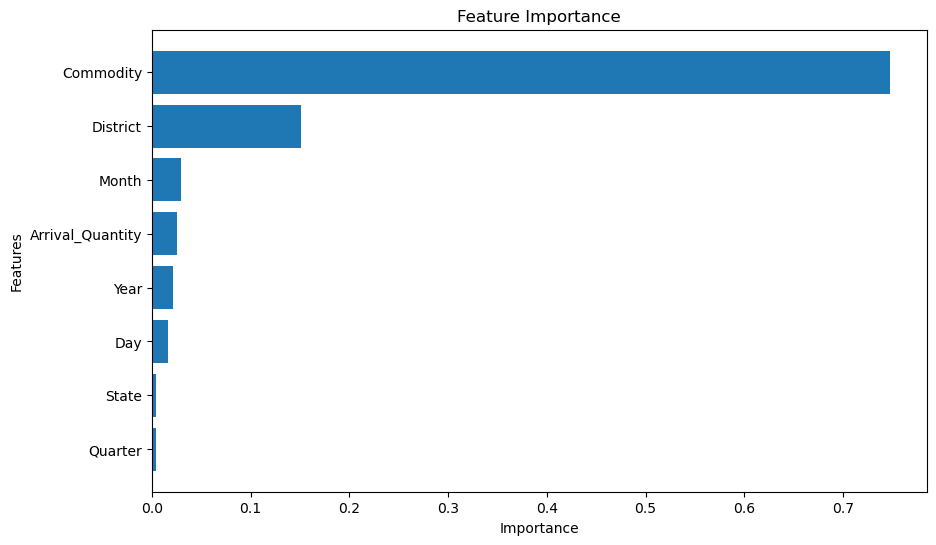

In [70]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.show()

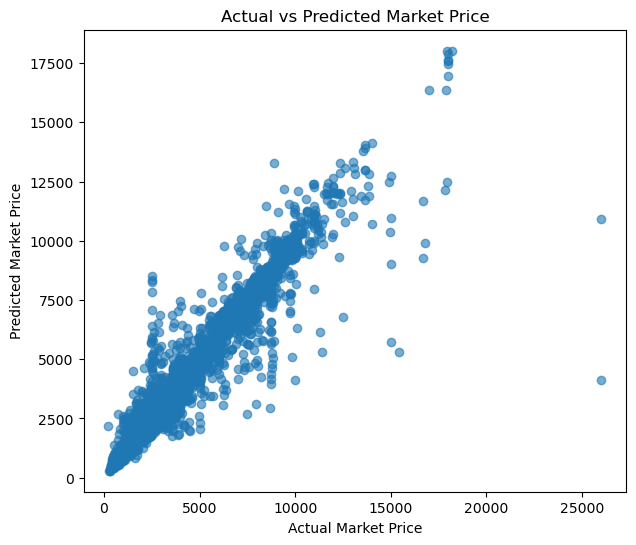

In [71]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Market Price")

plt.ylabel("Predicted Market Price")

plt.title("Actual vs Predicted Market Price")

plt.show()

## Actual vs Predicted Market Price

The Actual vs Predicted scatter plot demonstrates a strong positive relationship between the observed and predicted market prices.

Most observations lie close to the expected trend, indicating that the Random Forest model accurately predicts market prices for the majority of records.

A small number of outliers are observed at very high market prices. These deviations are expected due to rare commodity-price combinations and do not significantly affect the overall model performance.

The high R² score confirms the model's strong predictive capability.

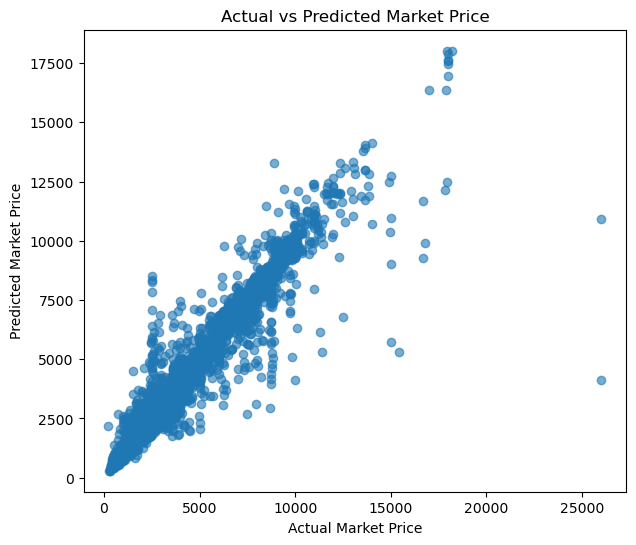

In [72]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Market Price")

plt.ylabel("Predicted Market Price")

plt.title("Actual vs Predicted Market Price")

plt.show()

# Residual Analysis

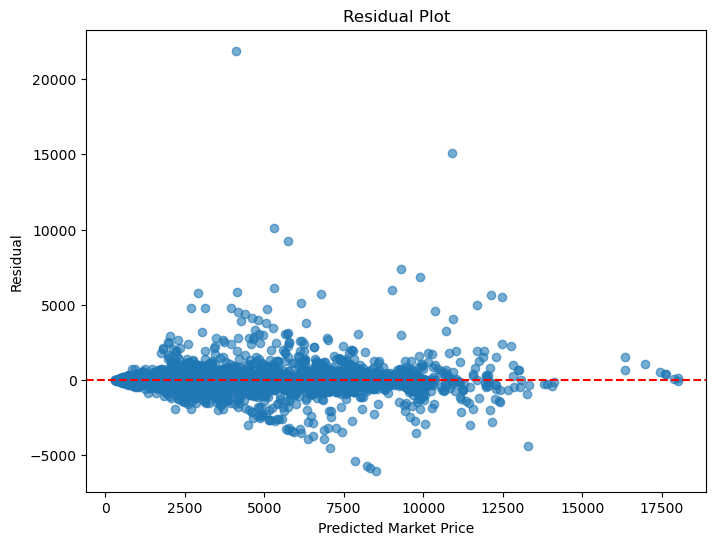

In [73]:
residual = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residual,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Market Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

## Residual Analysis

Residual analysis was performed to evaluate the prediction errors of the optimized Random Forest model.

The residual plot shows that most prediction errors are randomly distributed around the zero line, indicating that the model does not exhibit significant systematic bias.

A few large positive and negative residuals are present, suggesting that the model has difficulty predicting certain extreme market prices. These observations are likely caused by rare commodity-price combinations or unusual market conditions.

Overall, the residual distribution indicates that the Random Forest model generalizes well for the majority of the dataset.

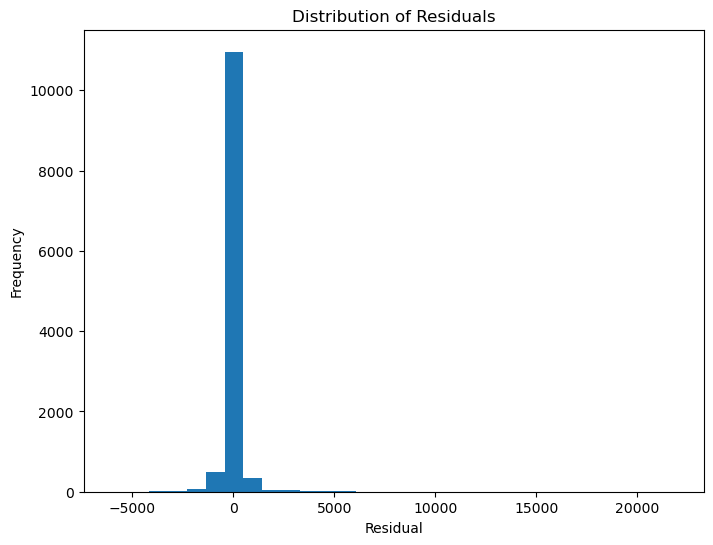

In [74]:
plt.figure(figsize=(8,6))

plt.hist(
    residual,
    bins=30
)

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.title("Distribution of Residuals")

plt.show()

## Distribution of Residuals

The residual distribution shows that most prediction errors are concentrated near zero, indicating accurate predictions for the majority of observations.

The presence of a small number of extreme residuals suggests occasional prediction errors for rare or highly volatile market conditions. However, these outliers represent only a small proportion of the dataset and do not significantly affect the overall predictive performance.

The residual distribution supports the conclusion that the Random Forest model provides reliable market price predictions.

In [75]:
print(X.columns)

Index(['Commodity', 'State', 'District', 'Day', 'Month', 'Year', 'Quarter',
       'Arrival_Quantity'],
      dtype='object')


In [76]:
new_data = pd.DataFrame({

    "Commodity": [14],

    "State": [2],

    "District": [15],

    "Day": [10],

    "Month": [8],

    "Year": [2026],

    "Quarter": [3],

    "Arrival_Quantity": [1000]

})

In [77]:
model = joblib.load("Market_Price_RF_Model.pkl")

In [78]:
model = best_model

In [79]:
prediction = model.predict(new_data)

print("Predicted Market Price:", prediction[0])

Predicted Market Price: 6485.549151898254


## 24. Testing the Trained Model with New Data

The trained Random Forest model was tested using a new unseen sample to verify its prediction capability.

The model successfully predicted the market price based on the encoded commodity, state, district, arrival quantity, and temporal features.

**Predicted Market Price:** ₹6485.55

This demonstrates that the trained model can generalize to unseen data and can be used for future agricultural market price prediction.

In [83]:
comparison_df = pd.DataFrame({
    "Actual_Market_Price": y_test.values,
    "Predicted_Market_Price": y_pred
})

comparison_df.head(20)

,Actual_Market_Price,Predicted_Market_Price
0,6987.788165,6914.990667
1,1986.000000,1651.428255
2,7081.364466,7054.615394
3,2179.000000,1942.679397
4,7384.000000,7356.597813
5,700.000000,700.626348
6,1629.144952,1751.950835
7,2171.000000,2172.702212
8,6976.807451,7171.148788
9,1000.000000,949.556669


In [80]:
joblib.dump(best_model, "market_price_rf_model.pkl")

['market_price_rf_model.pkl']

In [81]:
market.to_csv("Final_Market_Dataset.csv", index=False)

In [82]:
pred_df = X_test.copy()
pred_df["Actual_Price"] = y_test
pred_df["Predicted_Price"] = y_pred

pred_df.to_csv("Prediction_Results.csv", index=False)